In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [9]:
def get_ejected_initial_conditions(initial_df, final_df, mass_number):
    masses = final_df["mass"].unique()
    mass = masses[mass_number]

    ejected_ids = final_df.loc[
        (final_df["mass"] == mass) &
        (final_df["result"] == "Ejected"),
        "particle_id"
    ].unique()

    return initial_df[
        initial_df["particle_id"].isin(ejected_ids)
    ].copy()

In [28]:
df_i=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Particle_Tracking/local_20260916_170611-2_initial_particles.txt', header=None)
df_i.columns=['a','e','particle_id']
df_f=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/local_20260916_170611_ejection_results.txt', header=None)
df_f.columns = ['mass','time','result','particle_id']


In [29]:
df_e_3=get_ejected_initial_conditions(df_i,df_f,2)

In [24]:
df_e_2

,a,e,particle_id
0,1.361962,0.043503,7
1,0.791966,0.016667,1
4,1.252518,0.094536,2
5,1.435654,0.052496,6
7,1.481385,0.176713,5
...,...,...,...
789,1.033932,0.033914,770
791,1.709876,0.267506,783
793,0.855301,0.066538,781
795,0.785891,0.105445,791


(array([ 2.,  3.,  4.,  2.,  3.,  7.,  5.,  8.,  4.,  5.,  4.,  8.,  8.,
         4.,  3., 10.,  3.,  8.,  4.,  6.,  4.,  4.,  5.,  5.,  9.,  5.,
         3.,  8.,  0.,  8.,  2.,  8.,  3.,  5.,  7.,  5.,  5.,  8.,  2.,
         8.,  5.,  3.,  3.,  5.,  3.,  3.,  6.,  6., 10.,  6.,  7.,  9.,
         5.,  8.,  2.,  3.,  6.,  3.,  4.,  0.,  0.,  0.,  0.,  1.,  0.,
         0.,  2.,  1.,  3.,  2.,  2.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,
         1.,  1.]),
 array([0.70215297, 0.71675456, 0.73135615, 0.74595773, 0.76055932,
        0.77516091, 0.78976249, 0.80436408, 0.81896566, 0.83356725,
        0.84816884, 0.86277042, 0.87737201, 0.8919736 , 0.90657518,
        0.92117677, 0.93577835, 0.95037994, 0.96498153, 0.97958311,
        0.9941847 , 1.00878629, 1.02338787, 1.03798946, 1.05259104,
        1.06719263, 1.08179422, 1.0963958 , 1.11099739, 1.12559898,
        1.14020056, 1.15480215, 1.16940373, 1.18400532, 1.19860691,
        1.21320849, 1.22781008, 1.24241167, 1.25701325, 1.27161484

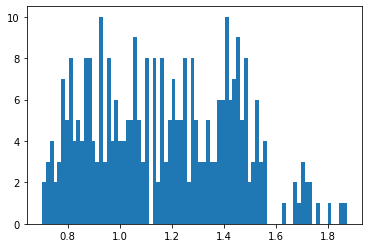

In [30]:
plt.hist(df_e_3.a, bins=80)

(array([ 7.,  7., 13.,  6.,  7.,  5., 13.,  5.,  7., 15., 11.,  7., 11.,
        13.,  8.,  9., 11., 10., 10.,  9.,  9.,  9., 18., 10., 10., 13.,
        11.,  9.,  9., 12., 13.,  6., 10., 12.,  6., 13., 15., 11., 10.,
         7.,  6., 12., 11.,  8.,  8., 12., 11., 10.,  8.,  9., 11., 11.,
         8., 11.,  7.,  8., 17., 12., 15., 13., 12., 13., 11., 18., 12.,
        12.,  4., 13., 16.,  7., 13., 14., 13.,  7., 10.,  8.,  4.,  2.,
         3.,  3.]),
 array([0.0818304 , 0.10571171, 0.12959302, 0.15347434, 0.17735565,
        0.20123696, 0.22511827, 0.24899958, 0.27288089, 0.29676221,
        0.32064352, 0.34452483, 0.36840614, 0.39228745, 0.41616876,
        0.44005008, 0.46393139, 0.4878127 , 0.51169401, 0.53557532,
        0.55945663, 0.58333795, 0.60721926, 0.63110057, 0.65498188,
        0.67886319, 0.70274451, 0.72662582, 0.75050713, 0.77438844,
        0.79826975, 0.82215106, 0.84603238, 0.86991369, 0.893795  ,
        0.91767631, 0.94155762, 0.96543893, 0.98932025, 1.01320156

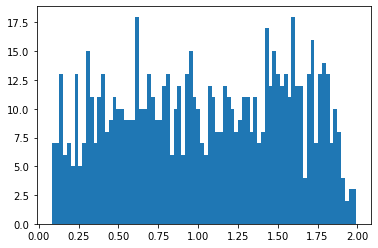

In [19]:
plt.hist(df_i.a, bins=80)

In [46]:
inner_edges= np.array([df_e['a'].min(),df_e_2['a'].min(),df_e_3['a'].min()])

In [33]:
masses=[0.01, 0.005011872336272725, 0.0025118864315095794]

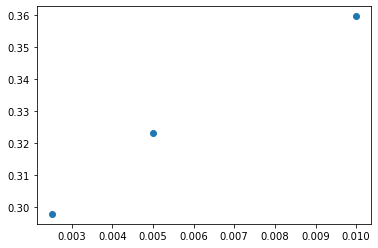

In [36]:
plt.scatter(masses, 1-inner_edges)

In [38]:
outer_edges= np.array([df_e['a'].max(),df_e_2['a'].max(),df_e_3['a'].max()])

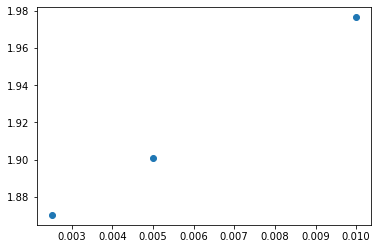

In [39]:
plt.scatter(masses, outer_edges)

In [40]:
def xpon(x,a,b,c):
    return a*x**b+c

In [47]:
curve_fit(xpon,masses,inner_edges)

/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_70160/3927744737.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  curve_fit(xpon,masses,inner_edges)


(array([ 8.40647564, 23.3731004 ,  0.6731631 ]),
 array([[inf, inf, inf],
        [inf, inf, inf],
        [inf, inf, inf]]))

In [45]:
curve_fit(xpon,masses,outer_edges)

/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_70160/3312595881.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  curve_fit(xpon,masses,outer_edges)


(array([49.25065145,  1.29304781,  1.84887623]),
 array([[inf, inf, inf],
        [inf, inf, inf],
        [inf, inf, inf]]))